# **PROYEK 1 : ANALISIS CUSTOMER CHURN**

**Import Library**



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# untuk setting visualisasi
sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("Telco Customer Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Data Cleaning**

In [3]:
# cek missing values
print(df.isnull().sum())

# hapus kolom yang tidak diperlukan
# Check if the column name is 'customerID' instead of 'CustomerID'
df.drop(['customerID'], axis=1, inplace=True)

#ubah kolom totalcharges ke float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


<ipython-input-3-7687dee8fe3d>:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


**Exploratory Data Analysis (EDA)**

Distribusi Churn

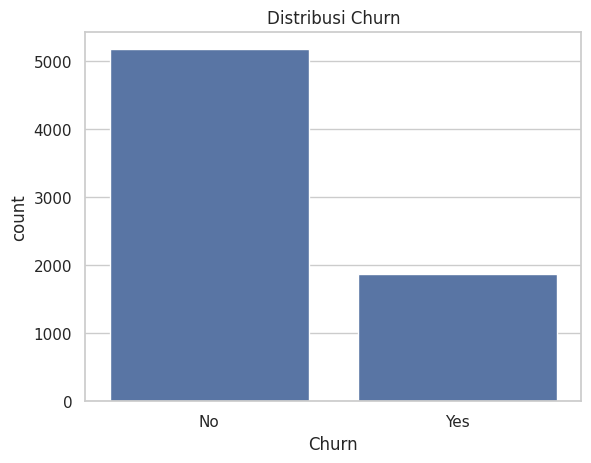

In [4]:
sns.countplot(x='Churn', data=df)
plt.title('Distribusi Churn')
plt.show()

**Churn berdasarkan jenis kontrak**

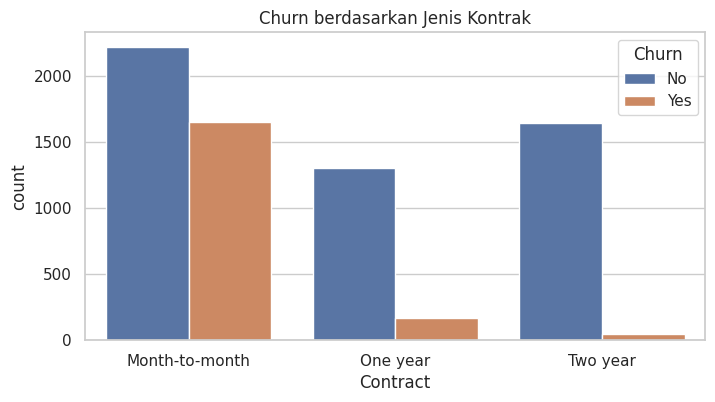

In [5]:
plt.figure(figsize=(8,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn berdasarkan Jenis Kontrak')
plt.show()

**Korelasi Numerik**

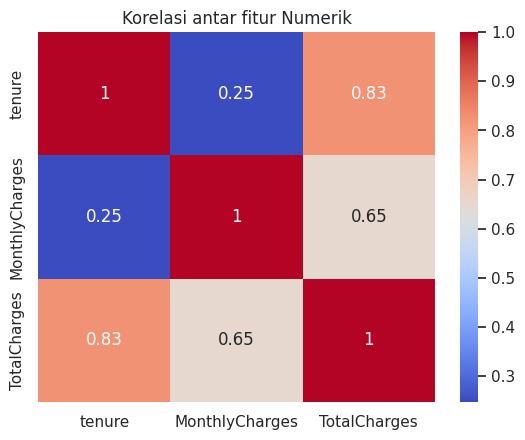

In [6]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr = df[numeric_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Korelasi antar fitur Numerik')
plt.show()

**Persentase Churn per Tipe Kontrak**

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


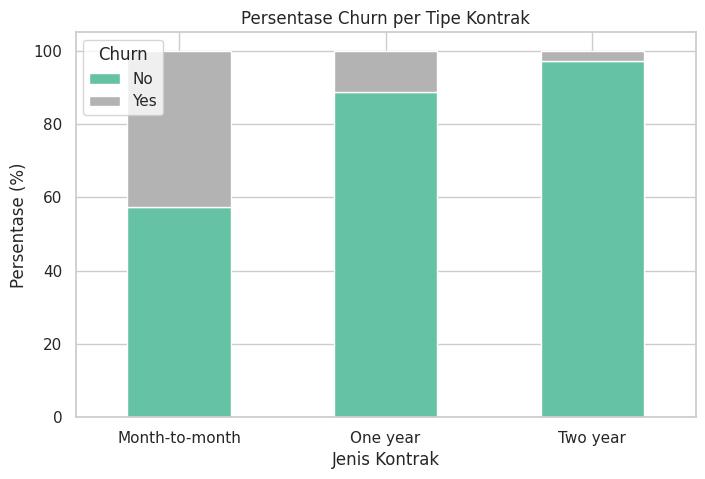

In [9]:
#Hitung persentase churn untuk setiap jenis kontrak
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
print(contract_churn)

#visualisasi
contract_churn.plot(kind='bar', stacked=True, figsize=(8,5), colormap='Set2')
plt.title('Persentase Churn per Tipe Kontrak')
plt.xlabel('Jenis Kontrak')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

**Rata-rata Tenure Pelanggan yang Churn vs Tidak**

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


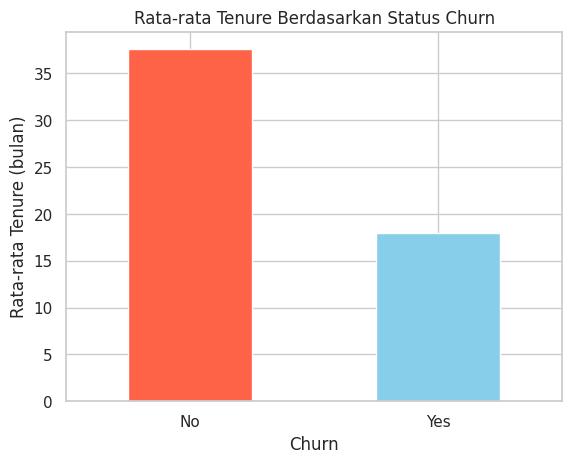

In [12]:
tenure_mean = df.groupby('Churn')['tenure'].mean()
print(tenure_mean)

#visualisasi
tenure_mean.plot(kind='bar', color=['tomato', 'skyblue'])
plt.title('Rata-rata Tenure Berdasarkan Status Churn')
plt.ylabel('Rata-rata Tenure (bulan)')
plt.xticks(rotation=0)
plt.show()

**Boxplot Biaya Bulanan vs Churn**

<ipython-input-13-9b97744d1403>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set3')


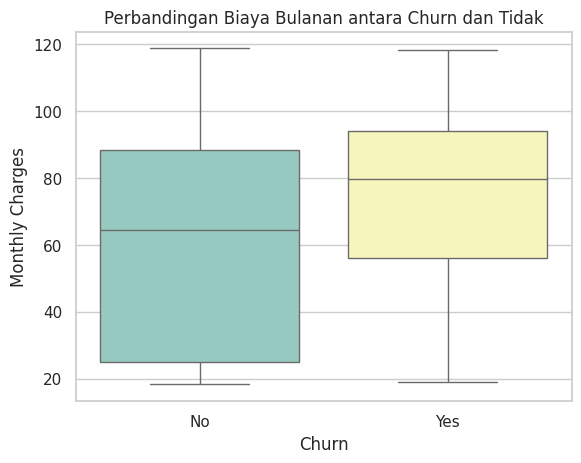

In [13]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set3')
plt.title('Perbandingan Biaya Bulanan antara Churn dan Tidak')
plt.ylabel('Monthly Charges')
plt.xlabel('Churn')
plt.show()


# **DASHBOARD VISUAL INTERAKTIF DI COLAB MENGGUNAKAN PLOTLY.EXPRESS**

In [14]:
import plotly.express as px

#Pie chart Churn
fig = px.pie(df, names='Churn', title='Distribusi Churn')
fig.show()

#Bar Chart Churn per jenis kontrak
fig = px.bar(df.groupby('Contract')['Churn']. value_counts().unstack(),
             barmode='group',title='Churn Berdasarkan Jenis Kontrak')
fig.show()

#Scatter plot Tenure vs Monthly Charges dengan warna churn
fig = px.scatter(df, x='tenure', y='MonthlyCharges', color='Churn',
                 title='Tenure vs Monthly Charges')
fig.show()


**Bar Chart - Churn Berdasarkan Jenis Internet Service**

In [15]:
fig = px.bar(df.groupby('InternetService')['Churn'].value_counts().unstack(),
             barmode='group',
             title='Churn Berdasarkan Jenis Layanan Internet',
             labels={'value': 'Jumlah Pelanggan'})
fig.show()

In [16]:
fig = px.histogram(df, x='tenure', nbins=20, color='Churn',
                   title='Distribusi Tenure Pelanggan Berdasarkan Churn')
fig.show()

In [17]:
fig = px.box(df, x='Churn', y='MonthlyCharges',
             title='Perbandingan Biaya Bulanan antara Churn vs Tidak')
fig.show()

In [18]:
import plotly.figure_factory as ff

corr = df.select_dtypes(include='number').corr()
z = corr.values
x = corr.columns.tolist()
y = x

fig = ff.create_annotated_heatmap(z, x=x, y=y, colorscale='Viridis', showscale=True)
fig.update_layout(title='Korelasi Antar Variabel Numerik')
fig.show()

In [19]:
fig = px.pie(df, names='gender', hole=0.5,
             title='Distribusi Gender Pelanggan')
fig.show()